## Initialization

In [1]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

import sys
import os

from collections import defaultdict
from typing import Callable, Dict, Any, List


current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)

['/home/hqdeng7/lijuyang/generalization', '/home/hqdeng7/.conda/envs/ljy/lib/python311.zip', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/lib-dynload', '', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/site-packages']


In [2]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

from ntk_result.trials.utils import *


import torchvision
import torchvision.transforms as transforms

data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [3]:
model200_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model200 = load_model_state_dict('cifar10', 'resnet20', 10, model200_path, 'cuda')
model100_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_100.pth'
model100 = load_model_state_dict('cifar10', 'resnet20', 10, model100_path, 'cuda')

  从字典中提取模型状态字典...
提取成功
  从字典中提取模型状态字典...
提取成功


In [4]:
def evaluate_model(model, dataloader, device='cuda'):
	model.to(device)
	model.eval()
	total_loss = 0.0
	correct = 0
	total = 0
	criterion = nn.CrossEntropyLoss()
	with torch.no_grad():
		for inputs, targets in dataloader:
			inputs, targets = inputs.to(device), targets.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, targets)
			total_loss += loss.item() * inputs.size(0)
			_, predicted = outputs.max(1)
			correct += predicted.eq(targets).sum().item()
			total += targets.size(0)
	avg_loss = total_loss / total
	acc = correct / total
	return avg_loss, acc


In [5]:
from torch.optim import SGD

def train_one_batch(model, batch, optimizer):
	model.train()
	criterion = nn.CrossEntropyLoss()

	inputs, targets = batch
	inputs, targets = inputs.cuda(), targets.cuda()

	optimizer.zero_grad()
	outputs = model(inputs)
	loss = criterion(outputs, targets)
	loss.backward()
	optimizer.step()

	print(f"One training step done. Loss: {loss.item():.4f}")

In [6]:
from torch.utils.data import Subset, DataLoader

train_subdl = DataLoader(train_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)

train_loss0, train_acc0 = evaluate_model(model100, train_subdl)
test_loss0, test_acc0 = evaluate_model(model100, test_dl)

In [7]:
from torch.utils.data import Subset, DataLoader
from loss_distribution.pytorch_script.models import get_model
import random
import io
import contextlib

In [8]:
def set_seed(seed):
    """设置随机种子以确保实验可复现"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # 以下两项是针对cuDNN的设置
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 设置环境变量，进一步增强确定性
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


def seed_worker(worker_id):
    """
    为每个Dataloader worker设置独立的种子。
    这对于可复现的数据增强非常重要。
    """
    worker_seed = torch.initial_seed()
    
    # 2. 为 numpy 设置种子
    np.random.seed(worker_seed + worker_id)
    
    # 3. 为 random 设置种子
    random.seed(worker_seed + worker_id)

## Results

In [9]:
def plot_training_losses(results_dict: dict, 
						 title: str = "Training Losses over Epochs",
						 figsize: tuple = (5, 3),
                         epoch_interval=0.5
                         ):
    """
    绘制 train_loss, test_loss, test_sub_loss 随 epoch 变化的曲线
    
    参数:
        results_dict: dict with keys 'train_loss', 'test_loss', 'test_sub_loss'
                     each value is np.ndarray of shape (6,) for epochs 0~5
        title: 图标题（可选）
    """
    epochs = [i * epoch_interval for i in np.arange(0, len(results_dict['train_loss']))]

    plt.figure(figsize=figsize)
    plt.plot(epochs, results_dict['train_loss'], 
             marker='o', label='Train Loss', linewidth=2, markersize=6)
    plt.plot(epochs, results_dict['test_loss'], 
             marker='s', label='Test Loss', linewidth=2, markersize=6)
    plt.plot(epochs, results_dict['test_sub_loss'], 
             marker='^', label='Test Sub Loss', linewidth=2, markersize=6)

    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(bottom=0)  # 纵坐标从 0 开始
    plt.xticks(epochs)  # 显示所有 epoch 刻度
    plt.tight_layout()
    plt.show()

In [13]:
def plot_training_losses(results_dict: dict, 
                        title: str = "Training Losses over Epochs",
                        figsize: tuple = (12, 4),
                        epoch_interval=0.5):
    """
    分别绘制不同范围的损失曲线
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    epochs = [i * epoch_interval for i in np.arange(0, len(results_dict['train_loss']))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # 左图：显示 train_loss 和 test_loss（较低范围）
    ax1.plot(epochs, results_dict['train_loss'], 
             marker='o', label='Train Loss', linewidth=2, markersize=6)
    ax1.plot(epochs, results_dict['test_loss'], 
             marker='s', label='Test Loss', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Train and Test Losses', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_ylim(0, max(max(results_dict['train_loss']), max(results_dict['test_loss'])) * 1.1)
    ax1.set_xticks(epochs)

    # 右图：显示 test_sub_loss（较高范围）
    ax2.plot(epochs, results_dict['test_sub_loss'], 
             marker='^', label='Test Sub Loss', linewidth=2, markersize=6, color='green')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Test Sub Loss', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.6)
    min_val = min(results_dict['test_sub_loss'])
    max_val = max(results_dict['test_sub_loss'])
    ax2.set_ylim(min_val * 0.9, max_val * 1.1)  # 留一点边距
    ax2.set_xticks(epochs)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [21]:
import pprint


def visualize_results_dict(results_dict, title):
	plot_training_losses(results_dict, title=title)
	rounded_dict = {key: [round(value, 4) for value in values] for key, values in results_dict.items()}
	pprint.pprint(rounded_dict, width=50, compact=True)

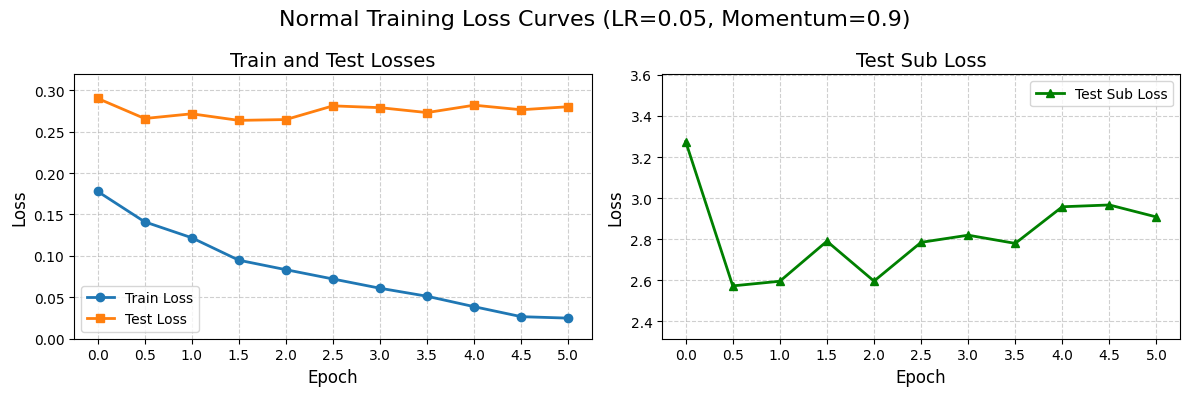

{'test_loss': [0.2901, 0.2658, 0.2715, 0.2635,
               0.2645, 0.281, 0.2789, 0.2729,
               0.2819, 0.2763, 0.28],
 'test_sub_loss': [3.2753, 2.5729, 2.5955, 2.7902,
                   2.5962, 2.7848, 2.8197, 2.7798,
                   2.9581, 2.9668, 2.9084],
 'train_loss': [0.1778, 0.1411, 0.1219, 0.0948,
                0.0833, 0.0721, 0.0609, 0.0513,
                0.0387, 0.0266, 0.0249]}


In [33]:
# normal train with lr=0.05
import pprint

results_dict = {'train_loss': [0.17784367995262146, 0.1410971928834915, 0.1218765637588501, 0.09477578934669495, 0.08332547618627548, 0.07210285425186157, 0.06092038222193718, 0.051256503247022626, 0.038661433967351916, 0.02661241720318794, 0.02485323562383652], 
 'test_loss': [0.29008910851478575, 0.26578320298194885, 0.2714660212993622, 0.26352498648166656, 0.2645266917705536, 0.2810440327644348, 0.278873992061615, 0.2729335593223572, 0.2818593379020691, 0.2763371033191681, 0.2800218494415283], 
 'test_sub_loss': [3.275315284729004, 2.5728888511657715, 2.595473051071167, 2.7902114391326904, 2.5961546897888184, 2.7848315238952637, 2.8197150230407715, 2.77978777885437, 2.958085298538208, 2.966841459274292, 2.90836238861084]}
 
visualize_results_dict(results_dict, title="Normal Training Loss Curves (LR=0.05, Momentum=0.9)")

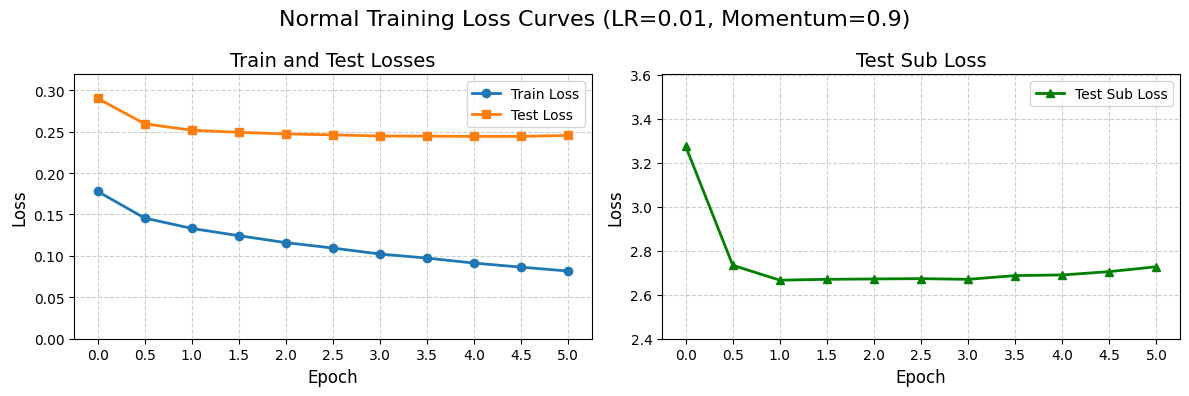

{'test_loss': [0.2901, 0.2594, 0.2517, 0.2491,
               0.2472, 0.2461, 0.2446, 0.2445,
               0.2442, 0.2442, 0.2453],
 'test_sub_loss': [3.2753, 2.7333, 2.6657, 2.6695,
                   2.6712, 2.6727, 2.6695, 2.6865,
                   2.6895, 2.7045, 2.7269],
 'train_loss': [0.1778, 0.1456, 0.1332, 0.1244,
                0.116, 0.1094, 0.1022, 0.0973,
                0.0913, 0.0864, 0.0817]}


In [32]:
from numpy import array

results_dict = {'train_loss': array([0.17784368, 0.14564713, 0.13315542, 0.12435028, 0.11596363,
       0.10942633, 0.10221716, 0.09730095, 0.09126985, 0.08637098,
       0.08168331]), 'test_loss': array([0.29008911, 0.25940482, 0.25165907, 0.2491111 , 0.24715224,
       0.24606349, 0.24463382, 0.24449022, 0.24421242, 0.24419219,
       0.2453348 ]), 'test_sub_loss': array([3.27531528, 2.733303  , 2.66565902, 2.66952932, 2.67117491,
       2.67267196, 2.6694521 , 2.68653421, 2.68946128, 2.70454531,
       2.72687962])}

visualize_results_dict(results_dict, 
					 title="Normal Training Loss Curves (LR=0.01, Momentum=0.9)")

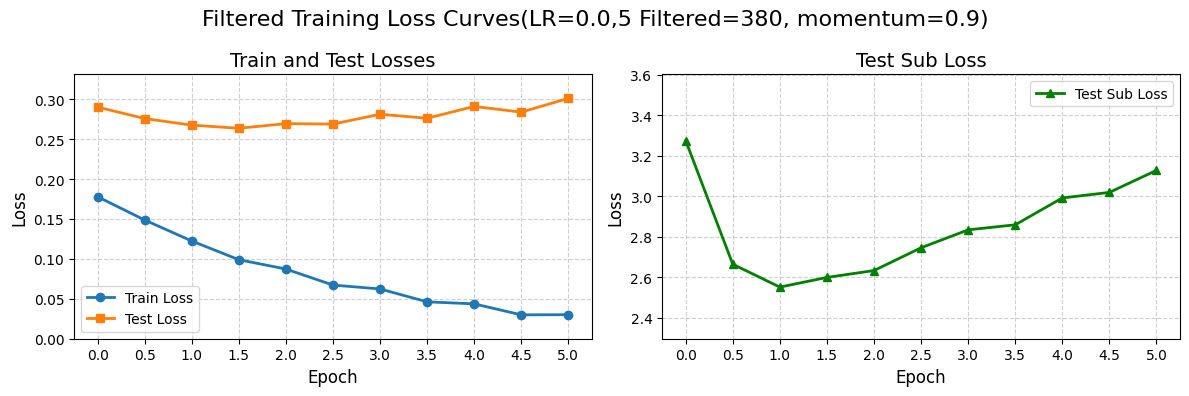

{'test_loss': [0.2901, 0.2758, 0.2675, 0.2636,
               0.2694, 0.2688, 0.2811, 0.2761,
               0.2909, 0.2838, 0.301],
 'test_sub_loss': [3.2753, 2.6644, 2.5513, 2.5991,
                   2.633, 2.7457, 2.8343, 2.8592,
                   2.9919, 3.0193, 3.1283],
 'train_loss': [0.1778, 0.1487, 0.1224, 0.099,
                0.0873, 0.0672, 0.0623, 0.0462,
                0.0437, 0.0299, 0.0301]}


In [ ]:
filtered_run_results_dict = {'train_loss': array([0.17784368, 0.14869281, 0.12239539, 0.09897312, 0.08728232,
       0.06720344, 0.06233305, 0.0462064 , 0.04365081, 0.02989478,
       0.03010186]), 'test_loss': array([0.29008911, 0.27575835, 0.26747703, 0.26359358, 0.2693638 ,
       0.26881548, 0.28113648, 0.27611499, 0.2909292 , 0.28377184,
       0.30101963]), 'test_sub_loss': array([3.27531528, 2.66442411, 2.55128818, 2.59912987, 2.63303998,
       2.74566875, 2.83426602, 2.85922685, 2.99189682, 3.01929202,
       3.12828381])}

visualize_results_dict(filtered_run_results_dict, 
					 title="Filtered Training Loss Curves(LR=0.0,5 Filtered=380, Momentum=0.9)")

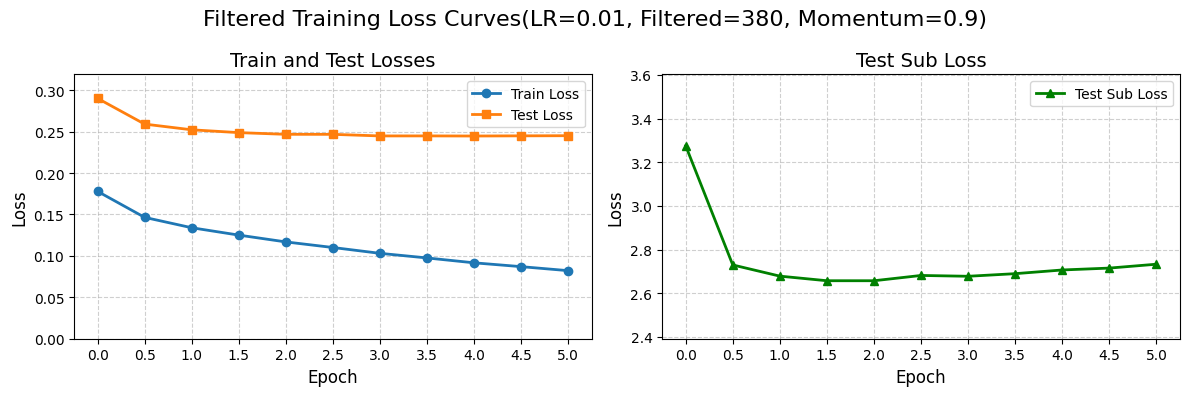

{'test_loss': [0.2901, 0.259, 0.2522, 0.2488,
               0.2467, 0.2467, 0.2447, 0.2448,
               0.2446, 0.2449, 0.245],
 'test_sub_loss': [3.2753, 2.7294, 2.6781, 2.657,
                   2.657, 2.6812, 2.6775, 2.6894,
                   2.7063, 2.715, 2.7328],
 'train_loss': [0.1778, 0.1465, 0.1339, 0.1251,
                0.1168, 0.1101, 0.1031, 0.0975,
                0.0916, 0.087, 0.0821]}


In [35]:
#### plot filtered training
filtered_run_results_dict = {'train_loss': array([0.17784368, 0.14645499, 0.13394355, 0.12505751, 0.11682878,
       0.11009552, 0.10305401, 0.09748374, 0.09159947, 0.08698378,
       0.08213324]), 'test_loss': array([0.29008911, 0.25903517, 0.25215176, 0.24875018, 0.24669082,
       0.24666692, 0.24474804, 0.24478842, 0.24465   , 0.24485708,
       0.2450248 ]), 'test_sub_loss': array([3.27531528, 2.72935288, 2.67808387, 2.65702505, 2.65699303,
       2.68121233, 2.67747133, 2.68940952, 2.70633609, 2.7149982 ,
       2.73276954])}

visualize_results_dict(filtered_run_results_dict, 
					 title="Filtered Training Loss Curves(LR=0.01, Filtered=380, Momentum=0.9)")

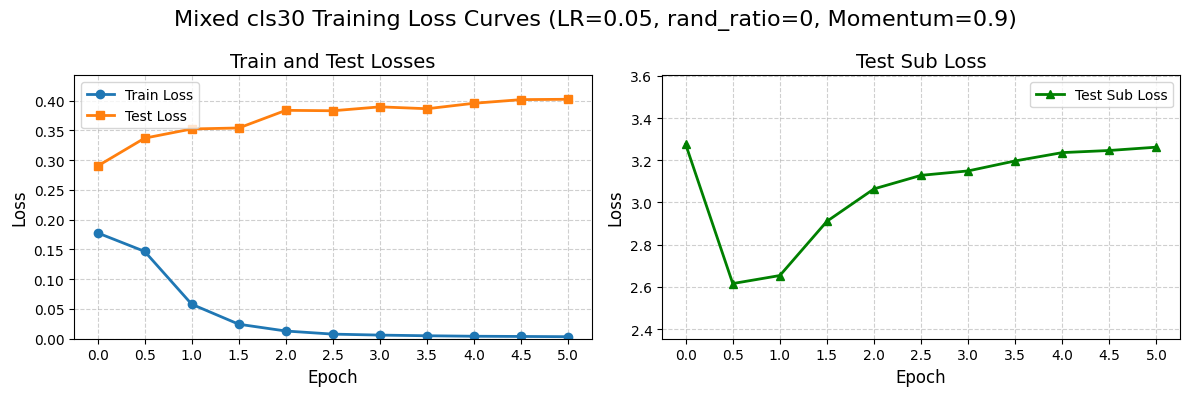

{'test_loss': [0.2901, 0.337, 0.3524, 0.3541,
               0.3837, 0.383, 0.3896, 0.3864,
               0.3956, 0.4017, 0.4023],
 'test_sub_loss': [3.2753, 2.6156, 2.6536, 2.9108,
                   3.0645, 3.1287, 3.1497, 3.1971,
                   3.2365, 3.2466, 3.2623],
 'train_loss': [0.1778, 0.1467, 0.0579, 0.0244,
                0.0129, 0.0077, 0.0061, 0.005,
                0.0042, 0.0038, 0.0034]}


In [34]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837, 0.02435289086484909, 0.012935646568775177, 0.0077286092755794525, 0.006088688850700855, 0.004977623375058174, 0.004165996117696166, 0.003802251220986247, 0.0034048756182044745], 
 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044, 0.3540900237560272, 0.38373733534812926, 0.3830185806751251, 0.3895860164642334, 0.3864222560405731, 0.39563698930740354, 0.40173564081192015, 0.4023042820453644], 
 'test_sub_loss': [3.275315284729004, 2.6155948638916016, 2.6536381244659424, 2.910794973373413, 3.0644798278808594, 3.1287002563476562, 3.1496968269348145, 3.197073459625244, 3.2364957332611084, 3.2465741634368896, 3.262263536453247]}
visualize_results_dict(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0, Momentum=0.9)")

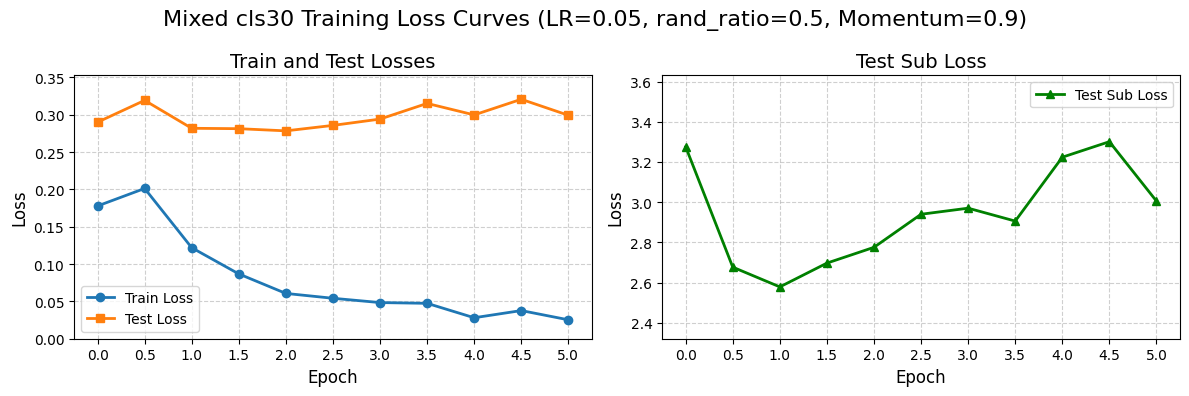

{'test_loss': [0.2901, 0.3193, 0.2819, 0.2814,
               0.2785, 0.2858, 0.2942, 0.3152,
               0.2998, 0.3208, 0.2993],
 'test_sub_loss': [3.2753, 2.6767, 2.5785, 2.6968,
                   2.7754, 2.9399, 2.9701, 2.9059,
                   3.2237, 3.301, 3.0054],
 'train_loss': [0.1778, 0.2013, 0.1219, 0.0868,
                0.0607, 0.0542, 0.0484, 0.0474,
                0.0281, 0.0377, 0.0253]}


In [36]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.20129895320129396, 0.12191601235961914, 0.08680833171701431, 0.06066989449596405, 0.05418569926023483, 0.04841889655184746, 0.04741781551873684, 0.028094663883209227, 0.03771534678554535, 0.02533280685776472], 
					  'test_loss': [0.29008910851478575, 0.3192882302761078, 0.28189442210197446, 0.28136772937774657, 0.2784577088832855, 0.28576665840148924, 0.2942238489151001, 0.31522144746780395, 0.29981594247817994, 0.3207595480442047, 0.2993498367071152], 
					  'test_sub_loss': [3.275315284729004, 2.6766574382781982, 2.578464984893799, 2.6968483924865723, 2.7754101753234863, 2.939864158630371, 2.970102071762085, 2.9059066772460938, 3.2237281799316406, 3.3009564876556396, 3.0053980350494385]}
visualize_results_dict(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0.5, Momentum=0.9)")

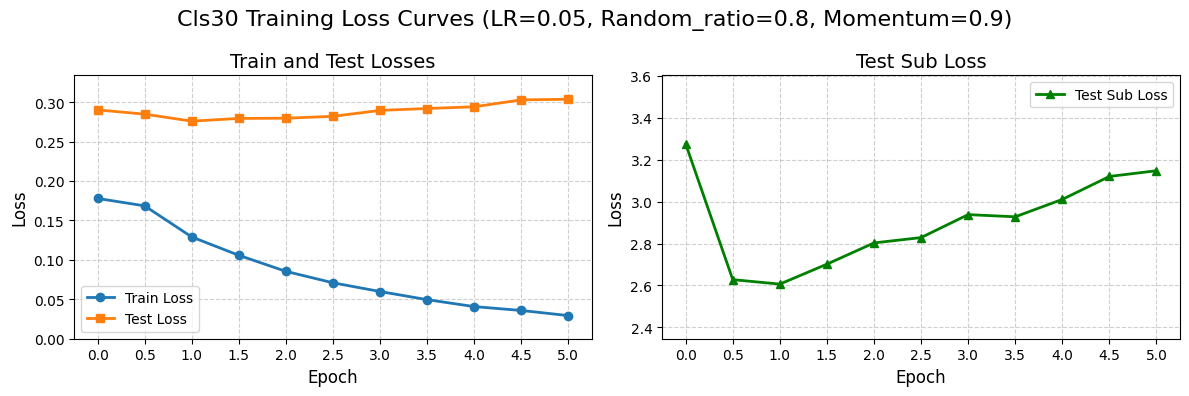

{'test_loss': [0.2901, 0.2847, 0.2758, 0.2793,
               0.2795, 0.2819, 0.2894, 0.2918,
               0.294, 0.3028, 0.3035],
 'test_sub_loss': [3.2753, 2.6278, 2.6065, 2.7017,
                   2.803, 2.8286, 2.9381, 2.9277,
                   3.0108, 3.1203, 3.1476],
 'train_loss': [0.1778, 0.1684, 0.129, 0.1058,
                0.0854, 0.0709, 0.0598, 0.0495,
                0.0407, 0.0358, 0.0293]}


In [37]:
cls30_results_dict = {'train_loss': array([0.17784368, 0.1684344 , 0.1290183 , 0.10575645, 0.08541117,
       0.07089877, 0.05984342, 0.04952571, 0.04072725, 0.03582791,
       0.02931708]), 'test_loss': array([0.29008911, 0.28471081, 0.2758248 , 0.2792608 , 0.27952979,
       0.28192633, 0.28942387, 0.29184299, 0.29403084, 0.30280663,
       0.3035446 ]), 'test_sub_loss': array([3.27531528, 2.62781963, 2.60650897, 2.70171258, 2.80302083,
       2.82857771, 2.93812983, 2.9277477 , 3.0107574 , 3.12028484,
       3.14759998])}

visualize_results_dict(cls30_results_dict, title="Cls30 Training Loss Curves (LR=0.05, Random_ratio=0.8, Momentum=0.9)")